<a href="https://colab.research.google.com/github/diklatbkpsdm23-blip/Smart-Farming-Bayam-Brazil/blob/main/Kel3bayam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - VISUALISASI MENARIK
# Kelompok 3 🍃 — Tambahkan cell ini di notebook Colab kamu
# =========================================================

# LANGKAH 0: Install library tambahan (jalankan sekali saja)
# !pip install plotly kaleido --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')


# =========================================================
# BAGIAN 1: TAMPILAN TABEL DATA LEBIH MENARIK
# Ganti cell "print(data.head())" dengan kode ini
# =========================================================

def tampilkan_tabel_menarik(df, judul="Dataset Kelembapan Bayam Brazil"):
    """Menampilkan tabel DataFrame dengan warna dan styling yang menarik."""

    def warna_status(val):
        if val == 'Ideal':
            return 'background-color: #d4edda; color: #155724; font-weight: bold'
        elif val == 'Basah':
            return 'background-color: #cce5ff; color: #004085; font-weight: bold'
        elif val == 'Kering':
            return 'background-color: #fff3cd; color: #856404; font-weight: bold'
        return ''

    def warna_kelembapan(val):
        try:
            val = float(val)
            if val < 60:
                return 'background-color: #fff3cd; color: #856404'
            elif val <= 79:
                return 'background-color: #d4edda; color: #155724'
            else:
                return 'background-color: #cce5ff; color: #004085'
        except:
            return ''

    styled = (
        df.head(10).style
        .applymap(warna_status, subset=['Status Tanah'])
        .applymap(warna_kelembapan, subset=['Kelembapan Tanah (%)'])
        .background_gradient(subset=['Suhu (°C)'], cmap='YlOrRd')
        .set_caption(f"📊 {judul} — 10 Data Teratas")
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '15px'), ('font-weight', 'bold'),
                       ('color', '#2c3e50'), ('margin-bottom', '10px')]},
            {'selector': 'th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-size', '13px'), ('padding', '10px 14px'),
                       ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('font-size', '12px'), ('padding', '8px 12px'),
                       ('text-align', 'center'), ('border-bottom', '1px solid #eee')]},
            {'selector': 'tr:hover td',
             'props': [('background-color', '#f0f8ff !important')]},
        ])
        .format({'Kelembapan Tanah (%)': '{:.0f}%', 'Suhu (°C)': '{:.1f}°C'})
    )

    display(styled)
    print(f"\n📈 Ringkasan Statistik Dataset:")
    print(f"   Total data   : {len(df):,} baris")
    print(f"   Kelembapan   : min={df['Kelembapan Tanah (%)'].min()}% | "
          f"max={df['Kelembapan Tanah (%)'].max()}% | "
          f"rata-rata={df['Kelembapan Tanah (%)'].mean():.1f}%")
    print(f"   Suhu         : min={df['Suhu (°C)'].min()}°C | "
          f"max={df['Suhu (°C)'].max()}°C | "
          f"rata-rata={df['Suhu (°C)'].mean():.1f}°C")
    print(f"   Distribusi status:")
    for status, count in df['Status Tanah'].value_counts().items():
        pct = count / len(df) * 100
        print(f"      {status:10s} : {count:4d} data ({pct:.1f}%)")


# =========================================================
# BAGIAN 2: GRAFIK TRAINING CNN YANG LEBIH MENARIK
# Ganti section "# 7. VISUALISASI PERFORMA CNN" dengan ini
# =========================================================

def plot_training_menarik(history, akurasi_test, epochs_total=30):
    """Visualisasi kurva training dengan desain modern dan informatif."""

    fig = plt.figure(figsize=(16, 10))
    fig.patch.set_facecolor('#0d1117')

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    warna_bg     = '#0d1117'
    warna_panel  = '#161b22'
    warna_border = '#30363d'
    warna_text   = '#e6edf3'
    warna_muted  = '#8b949e'

    # --- CARD METRIC ATAS ---
    metric_data = [
        ("Akurasi Akhir",  f"{akurasi_test*100:.2f}%", "#58a6ff"),
        ("Best Val Acc",   f"{max(history.history['val_accuracy'])*100:.2f}%", "#3fb950"),
        ("Final Loss",     f"{history.history['loss'][-1]:.4f}", "#f78166"),
    ]

    for col, (label, val, warna) in enumerate(metric_data):
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor(warna_panel)
        for spine in ax.spines.values():
            spine.set_edgecolor(warna_border)
            spine.set_linewidth(1.2)
        ax.set_xticks([]); ax.set_yticks([])

        ax.text(0.5, 0.7, val, transform=ax.transAxes,
                ha='center', va='center', fontsize=30, fontweight='bold',
                color=warna)
        ax.text(0.5, 0.25, label, transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color=warna_muted)

        rect = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                              boxstyle="round,pad=0.02",
                              linewidth=1.5, edgecolor=warna,
                              facecolor='none', transform=ax.transAxes,
                              alpha=0.4)
        ax.add_patch(rect)

    # --- KURVA AKURASI ---
    ax_acc = fig.add_subplot(gs[1, :2])
    ax_acc.set_facecolor(warna_panel)
    for spine in ax_acc.spines.values():
        spine.set_edgecolor(warna_border)

    ep = range(1, len(history.history['accuracy']) + 1)
    ax_acc.plot(ep, history.history['accuracy'],
                color='#58a6ff', linewidth=2.2, label='Training Accuracy', zorder=3)
    ax_acc.plot(ep, history.history['val_accuracy'],
                color='#3fb950', linewidth=2.2, linestyle='--',
                label='Validation Accuracy', zorder=3)
    ax_acc.fill_between(ep, history.history['accuracy'],
                        history.history['val_accuracy'],
                        alpha=0.08, color='#58a6ff')

    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    best_val   = max(history.history['val_accuracy'])
    ax_acc.axvline(best_epoch, color='#f0883e', linestyle=':', linewidth=1.5, alpha=0.7)
    ax_acc.annotate(f'Best: {best_val*100:.1f}%\n(epoch {best_epoch})',
                    xy=(best_epoch, best_val),
                    xytext=(best_epoch + 2, best_val - 0.08),
                    color='#f0883e', fontsize=9,
                    arrowprops=dict(arrowstyle='->', color='#f0883e', lw=1.2))

    ax_acc.set_title('Kurva Akurasi Model CNN', color=warna_text,
                     fontsize=13, fontweight='bold', pad=12)
    ax_acc.set_xlabel('Epoch', color=warna_muted, fontsize=10)
    ax_acc.set_ylabel('Akurasi', color=warna_muted, fontsize=10)
    ax_acc.tick_params(colors=warna_muted)
    ax_acc.grid(True, alpha=0.15, color=warna_border)
    ax_acc.legend(facecolor=warna_panel, edgecolor=warna_border,
                  labelcolor=warna_text, fontsize=9)
    ax_acc.set_ylim(0.35, 1.05)

    # --- KURVA LOSS ---
    ax_loss = fig.add_subplot(gs[1, 2])
    ax_loss.set_facecolor(warna_panel)
    for spine in ax_loss.spines.values():
        spine.set_edgecolor(warna_border)

    ax_loss.plot(ep, history.history['loss'],
                 color='#f78166', linewidth=2.2, label='Training Loss')
    ax_loss.plot(ep, history.history['val_loss'],
                 color='#d2a8ff', linewidth=2.2, linestyle='--',
                 label='Validation Loss')
    ax_loss.set_title('Kurva Loss CNN', color=warna_text,
                      fontsize=13, fontweight='bold', pad=12)
    ax_loss.set_xlabel('Epoch', color=warna_muted, fontsize=10)
    ax_loss.set_ylabel('Loss', color=warna_muted, fontsize=10)
    ax_loss.tick_params(colors=warna_muted)
    ax_loss.grid(True, alpha=0.15, color=warna_border)
    ax_loss.legend(facecolor=warna_panel, edgecolor=warna_border,
                   labelcolor=warna_text, fontsize=9)

    # --- JUDUL UTAMA ---
    fig.suptitle('🌿 Smart Farming Bayam Brazil — Analisis Performa Model CNN',
                 fontsize=15, fontweight='bold', color=warna_text, y=1.01)

    plt.savefig('grafik_training_cnn.png', dpi=150, bbox_inches='tight',
                facecolor=warna_bg)
    plt.show()
    print("✅ Grafik disimpan sebagai 'grafik_training_cnn.png'")


# =========================================================
# BAGIAN 3: GRAFIK REALTIME YANG LEBIH MENARIK
# Ganti bagian RENDERING di dalam while loop dengan ini
# =========================================================

def plot_realtime_menarik(kelembapan_history, lscm_predictions,
                          kelembapan, suhu, status_tanah_cnn,
                          status_pompa, tren_berikutnya, counter):
    """Grafik monitoring realtime dengan tampilan dark mode modern."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                   gridspec_kw={'width_ratios': [3, 1]})
    fig.patch.set_facecolor('#0d1117')

    warna_bg    = '#0d1117'
    warna_panel = '#161b22'
    warna_text  = '#e6edf3'
    warna_muted = '#8b949e'
    warna_bdr   = '#30363d'

    # --- PANEL KIRI: GRAFIK KELEMBAPAN ---
    ax1.set_facecolor(warna_panel)
    for sp in ax1.spines.values():
        sp.set_edgecolor(warna_bdr)

    x = range(len(kelembapan_history))
    ax1.plot(x, kelembapan_history, color='#58a6ff', linewidth=1.8,
             label='Sensor Realtime', zorder=3)
    ax1.fill_between(x, kelembapan_history, 30, alpha=0.1, color='#58a6ff')
    ax1.plot(x, lscm_predictions, color='#f0883e', linewidth=2,
             linestyle='--', label='Tren LSCM', zorder=4)

    ax1.axhline(60, color='#f78166', linestyle=':', linewidth=1.4,
                alpha=0.8, label='Batas Kering (60%)')
    ax1.axhline(80, color='#3fb950', linestyle=':', linewidth=1.4,
                alpha=0.8, label='Batas Basah (80%)')

    ax1.fill_between(x, 30, 60, alpha=0.04, color='#f78166')
    ax1.fill_between(x, 60, 80, alpha=0.04, color='#3fb950')
    ax1.fill_between(x, 80, 110, alpha=0.04, color='#58a6ff')

    ax1.text(2, 55, 'KERING', color='#f78166', fontsize=8, alpha=0.7)
    ax1.text(2, 73, 'IDEAL', color='#3fb950', fontsize=8, alpha=0.7)
    ax1.text(2, 85, 'BASAH', color='#58a6ff', fontsize=8, alpha=0.7)

    ax1.set_title(f'📡 Monitoring Kelembapan Realtime — Log ke-{counter}',
                  color=warna_text, fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Data Berjalan (100 Terakhir)', color=warna_muted, fontsize=9)
    ax1.set_ylabel('Kelembapan Tanah (%)', color=warna_muted, fontsize=9)
    ax1.set_ylim(30, 110)
    ax1.tick_params(colors=warna_muted, labelsize=9)
    ax1.grid(axis='y', alpha=0.12, color=warna_bdr)
    ax1.legend(facecolor=warna_panel, edgecolor=warna_bdr,
               labelcolor=warna_text, fontsize=8, loc='upper left')

    # Titik data terbaru
    ax1.scatter([len(kelembapan_history) - 1], [kelembapan_history[-1]],
                color='#58a6ff', s=60, zorder=5)
    ax1.annotate(f'{kelembapan_history[-1]}%',
                 xy=(len(kelembapan_history) - 1, kelembapan_history[-1]),
                 xytext=(-30, 10), textcoords='offset points',
                 color='#58a6ff', fontsize=9, fontweight='bold')

    # --- PANEL KANAN: CARD STATUS ---
    ax2.set_facecolor(warna_panel)
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
    ax2.axis('off')

    if 'MENYALA' in status_pompa:
        warna_pompa = '#f78166'
        icon_pompa  = '🔥'
    elif 'BASAH' in status_pompa:
        warna_pompa = '#58a6ff'
        icon_pompa  = '💧'
    else:
        warna_pompa = '#3fb950'
        icon_pompa  = '✅'

    warna_cnn = {'Ideal': '#3fb950', 'Basah': '#58a6ff', 'Kering': '#f78166'}
    w_cnn = warna_cnn.get(status_tanah_cnn, '#e6edf3')

    items = [
        (0.88, '🌡️', 'Kelembapan Tanah', f'{kelembapan}%', '#58a6ff'),
        (0.70, '🌡️', 'Suhu Udara', f'{suhu}°C', '#f0883e'),
        (0.52, '🤖', 'CNN Klasifikasi', status_tanah_cnn, w_cnn),
        (0.34, '📈', 'Tren LSCM', f'{tren_berikutnya:.1f}%', '#d2a8ff'),
        (0.14, icon_pompa, 'Pompa Air', 'MENYALA' if 'MENYALA' in status_pompa else 'MATI', warna_pompa),
    ]

    for y, icon, label, nilai, warna in items:
        ax2.text(0.08, y + 0.04, icon, fontsize=14, va='center')
        ax2.text(0.22, y + 0.06, label, color=warna_muted, fontsize=8, va='center')
        ax2.text(0.22, y - 0.02, nilai, color=warna, fontsize=13,
                 fontweight='bold', va='center')
        ax2.axhline(y - 0.09, color=warna_bdr, linewidth=0.5, alpha=0.5)

    ax2.set_title('Status Sensor', color=warna_text,
                  fontsize=11, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.show()


# =========================================================
# BAGIAN 4: DISTRIBUSI DATA & PIE CHART STATUS TANAH
# Tambahkan cell baru di awal atau setelah loading data
# =========================================================

def plot_distribusi_data(df):
    """Visualisasi distribusi data: status tanah, kelembapan, suhu."""

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor('#0d1117')
    warna_bg    = '#0d1117'
    warna_panel = '#161b22'
    warna_bdr   = '#30363d'
    warna_text  = '#e6edf3'
    warna_muted = '#8b949e'

    # 1. Pie chart distribusi status
    ax = axes[0]
    ax.set_facecolor(warna_panel)
    counts = df['Status Tanah'].value_counts()
    warna_pie = {'Ideal': '#3fb950', 'Basah': '#58a6ff', 'Kering': '#f78166'}
    colors = [warna_pie.get(s, '#8b949e') for s in counts.index]
    wedges, texts, autotexts = ax.pie(
        counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='#0d1117', linewidth=2),
        textprops=dict(color=warna_text, fontsize=10)
    )
    for at in autotexts:
        at.set_color('#0d1117')
        at.set_fontweight('bold')
    ax.set_title('Distribusi Status Tanah', color=warna_text,
                 fontsize=12, fontweight='bold', pad=12)

    # 2. Histogram kelembapan
    ax2 = axes[1]
    ax2.set_facecolor(warna_panel)
    for sp in ax2.spines.values():
        sp.set_edgecolor(warna_bdr)
    ax2.hist(df['Kelembapan Tanah (%)'], bins=25,
             color='#58a6ff', edgecolor='#0d1117', linewidth=0.5, alpha=0.85)
    ax2.axvline(60, color='#f78166', linestyle='--', linewidth=1.5,
                label='Batas kering (60%)')
    ax2.axvline(80, color='#3fb950', linestyle='--', linewidth=1.5,
                label='Batas basah (80%)')
    ax2.set_title('Distribusi Kelembapan Tanah', color=warna_text,
                  fontsize=12, fontweight='bold', pad=12)
    ax2.set_xlabel('Kelembapan (%)', color=warna_muted, fontsize=9)
    ax2.set_ylabel('Jumlah Data', color=warna_muted, fontsize=9)
    ax2.tick_params(colors=warna_muted)
    ax2.grid(axis='y', alpha=0.12, color=warna_bdr)
    ax2.legend(facecolor=warna_panel, edgecolor=warna_bdr,
               labelcolor=warna_text, fontsize=8)

    # 3. Scatter plot kelembapan vs suhu
    ax3 = axes[2]
    ax3.set_facecolor(warna_panel)
    for sp in ax3.spines.values():
        sp.set_edgecolor(warna_bdr)
    for status, warna in warna_pie.items():
        mask = df['Status Tanah'] == status
        ax3.scatter(df.loc[mask, 'Kelembapan Tanah (%)'],
                    df.loc[mask, 'Suhu (°C)'],
                    c=warna, label=status, alpha=0.4, s=8)
    ax3.set_title('Kelembapan vs Suhu per Status', color=warna_text,
                  fontsize=12, fontweight='bold', pad=12)
    ax3.set_xlabel('Kelembapan Tanah (%)', color=warna_muted, fontsize=9)
    ax3.set_ylabel('Suhu (°C)', color=warna_muted, fontsize=9)
    ax3.tick_params(colors=warna_muted)
    ax3.grid(alpha=0.12, color=warna_bdr)
    ax3.legend(facecolor=warna_panel, edgecolor=warna_bdr,
               labelcolor=warna_text, fontsize=9)

    fig.suptitle('🌿 Eksplorasi Dataset — Smart Farming Bayam Brazil',
                 fontsize=14, fontweight='bold', color=warna_text, y=1.02)
    plt.tight_layout()
    plt.savefig('distribusi_data.png', dpi=150, bbox_inches='tight',
                facecolor=warna_bg)
    plt.show()
    print("✅ Grafik disimpan sebagai 'distribusi_data.png'")


# =========================================================
# CARA PENGGUNAAN — SALIN BARIS DI BAWAH INI KE CELL COLAB
# =========================================================

# ── Setelah data = pd.read_excel(...) ──
# tampilkan_tabel_menarik(data)
# plot_distribusi_data(data)

# ── Setelah model.fit(...) selesai ──
# loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
# plot_training_menarik(history, accuracy)

# ── Di dalam while loop realtime, ganti plt.figure(...) s.d. plt.show() dengan: ──
# plot_realtime_menarik(
#     kelembapan_history, lscm_predictions,
#     kelembapan, suhu, status_tanah_cnn,
#     status_pompa, tren_berikutnya, counter
# )

In [41]:
# Memastikan library yang dibutuhkan sudah siap
import os
print("Sistem Siap. Pastikan file 'Data_Kelembapan_Bayam_Brazil_1440.xlsx' sudah diupload ke menu Files di kiri.")

Sistem Siap. Pastikan file 'Data_Kelembapan_Bayam_Brazil_1440.xlsx' sudah diupload ke menu Files di kiri.


[INFO] Dataset berhasil dimuat! Menampilkan 5 data teratas:


,No,Tanggal,Jam,Kelembapan Tanah (%),Suhu (°C),Status Tanah
0,1,01 May 2026,00:00,71%,24.1°C,Ideal
1,2,01 May 2026,00:31,76%,25.0°C,Ideal
2,3,01 May 2026,01:02,72%,26.9°C,Ideal
3,4,01 May 2026,01:33,85%,24.3°C,Basah
4,5,01 May 2026,02:04,81%,24.1°C,Basah
5,6,01 May 2026,02:35,70%,24.9°C,Ideal
6,7,01 May 2026,03:06,84%,26.4°C,Basah
7,8,01 May 2026,03:37,85%,24.8°C,Basah
8,9,01 May 2026,04:08,85%,25.7°C,Basah
9,10,01 May 2026,04:39,82%,26.4°C,Basah



📈 Ringkasan Statistik Dataset:
   Total data   : 1,440 baris
   Kelembapan   : min=50% | max=98% | rata-rata=75.1%
   Suhu         : min=24.0°C | max=33.0°C | rata-rata=28.3°C
   Distribusi status:
      Ideal      :  801 data (55.6%)
      Basah      :  527 data (36.6%)
      Kering     :  112 data (7.8%)


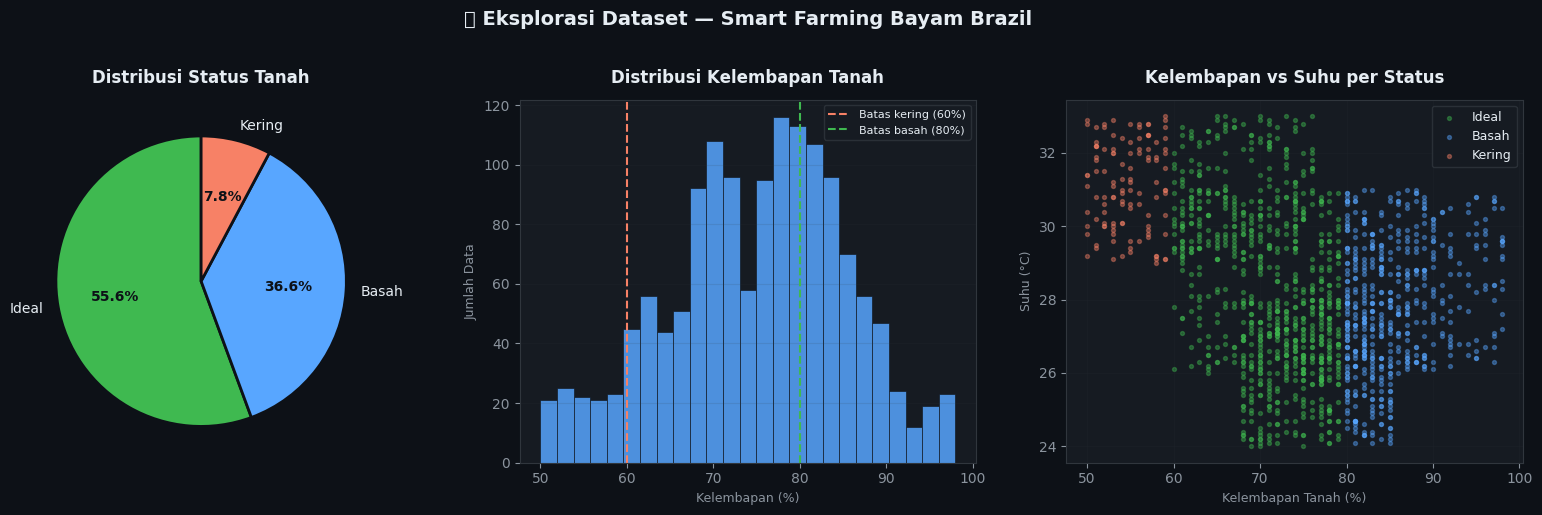

✅ Grafik disimpan sebagai 'distribusi_data.png'

--- Memulai Proses Training CNN (30 Epochs) ---
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5226 - loss: 2.3279 - val_accuracy: 0.7257 - val_loss: 0.7357
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6641 - loss: 0.8099 - val_accuracy: 0.7257 - val_loss: 0.5658
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7118 - loss: 0.5957 - val_accuracy: 0.7639 - val_loss: 0.4794
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7613 - loss: 0.5272 - val_accuracy: 0.7951 - val_loss: 0.4777
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7734 - loss: 0.4996 - val_accuracy: 0.8264 - val_loss: 0.4606
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7951 - loss: 0.4808 - val_accuracy: 0.8472 - val_loss: 0.4231
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7856 - loss: 0.4719 - val_accuracy: 0.8299 - val_loss: 0.3926
Epoch 8/30
72/72 ━━━━


Akurasi Pengujian Model CNN: 85.76%
[SUKSES] Model berhasil disimpan.


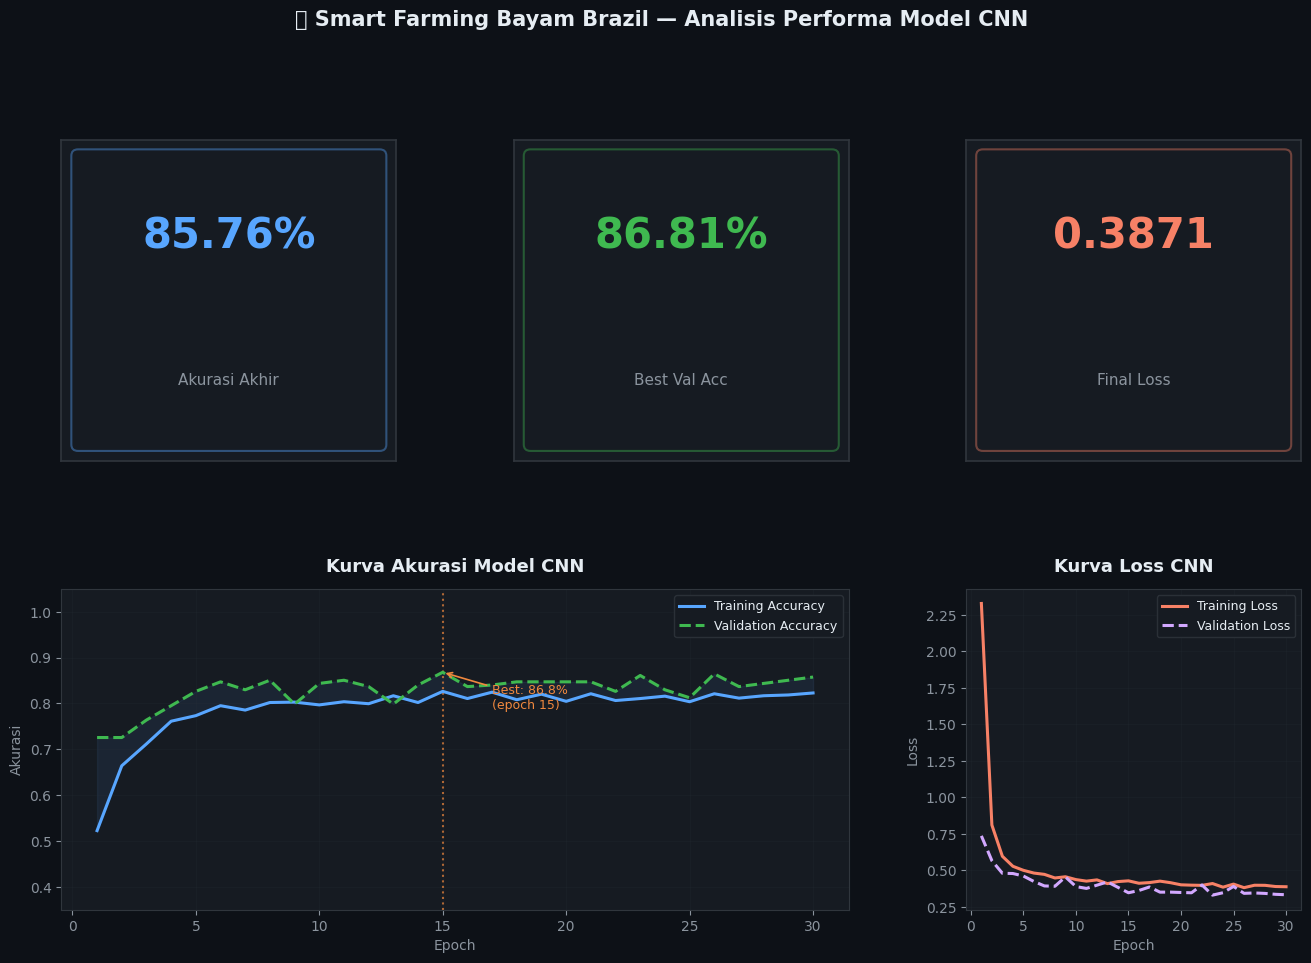

✅ Grafik disimpan sebagai 'grafik_training_cnn.png'


In [46]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - TRAINING & EVALUATION PHASE
# Kelompok 3 🍃
# =========================================================

import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# 1. MEMBACA DATASET
nama_file = "Data_Kelembapan_Bayam_Brazil_1440.xlsx"

if os.path.exists(nama_file):
    data = pd.read_excel(nama_file)
    print("[INFO] Dataset berhasil dimuat! Menampilkan 5 data teratas:")
    tampilkan_tabel_menarik(data)
    plot_distribusi_data(data)
else:
    raise FileNotFoundError(f"File '{nama_file}' tidak ditemukan. Silahkan upload file tersebut ke tab Files (ikon folder) di sebelah kiri Colab Anda terlebih dahulu.")

# 2. PREPROCESSING DATA
encoder = LabelEncoder()
data['Status_Encode'] = encoder.fit_transform(data['Status Tanah'])

# Fitur input: Kelembapan Tanah dan Suhu Udara
X = data[['Kelembapan Tanah (%)', 'Suhu (°C)']].values
y = data['Status_Encode'].values

# Reshape untuk struktur input CNN (samples, features, channels)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data training dan testing (80% : 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ARSITEKTUR MODEL CNN
model = Sequential([
    Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(2,1)),
    MaxPooling1D(pool_size=1),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(encoder.classes_), activation='softmax')
])

# 4. COMPILE & TRAIN MODEL
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Memulai Proses Training CNN (30 Epochs) ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# 5. EVALUASI MODEL
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAkurasi Pengujian Model CNN: {accuracy * 100:.2f}%")

# 6. SIMPAN MODEL & ENCODER
model.save("model_cnn_bayam_brazil.h5")
with open("encoder_bayam_brazil.pkl", "wb") as f:
    pickle.dump(encoder, f)
print("[SUKSES] Model berhasil disimpan.")

# ✅ TAMBAHAN — ganti plt lama dengan ini
plot_training_menarik(history, accuracy)



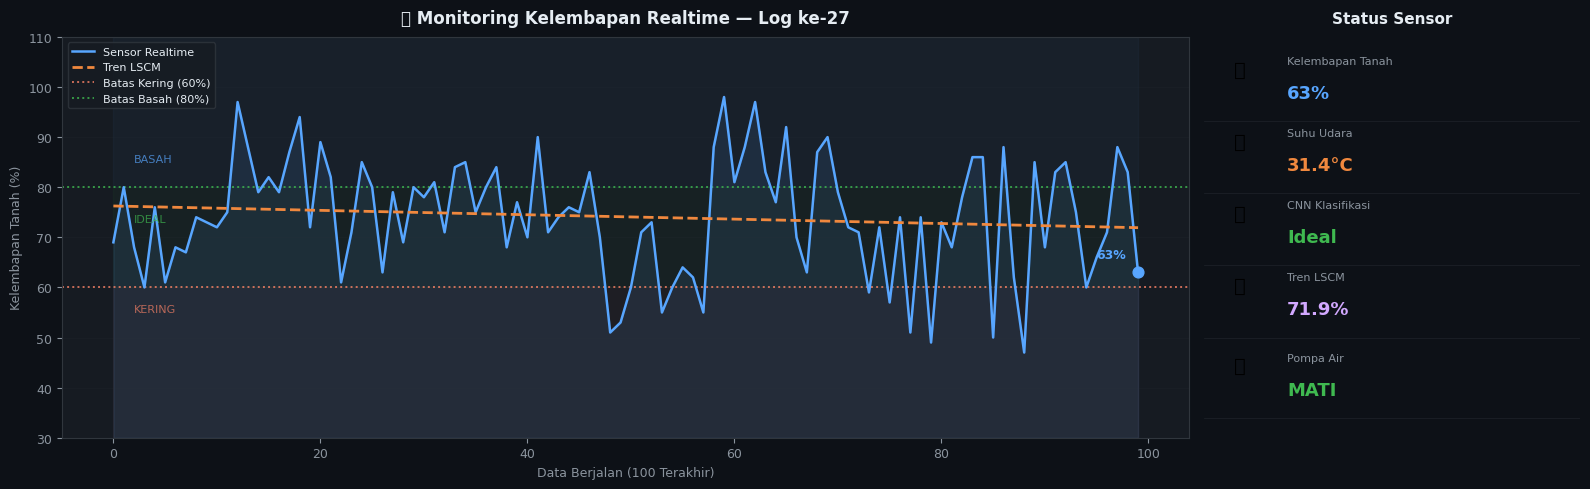

 DATA DASHBOARD MONITORING REALTIME - LOG KE-27
 🟢 BACA SENSOR -> Kelembapan: 63%  |  Suhu: 31.4°C
 🤖 MODEL CNN   -> Status Tanah  : Ideal
 📈 MODEL LSCM  -> Tren Berikutnya: 71.92%
 ⚡ AUTOMATION  -> Pompa         : 🛑 POMPA AIR MATI (Kondisi Ideal)
💡 Tips: Klik Stop di kiri cell untuk mengakhiri.

[INFO] Sistem Monitoring Realtime Berhasil Dimatikan.


In [43]:
import time
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from IPython.display import clear_output

# 1. AMBIL KONFIGURASI MODEL & DATASET HISTORIS
print("Mengintegrasikan Model dan Grafik Ke Dalam Sistem Realtime...")
model_realtime = tf.keras.models.load_model("model_cnn_bayam_brazil.h5")

with open("encoder_bayam_brazil.pkl", "rb") as f:
    encoder_realtime = pickle.load(f)

# Membaca data historis asli sebagai basis awal algoritma LSCM
data_historis = pd.read_excel("Data_Kelembapan_Bayam_Brazil_1440.xlsx")

# Membatasi window awal grafik mengambil 100 data terakhir dari excel agar tidak menumpuk
kelembapan_history = data_historis['Kelembapan Tanah (%)'].iloc[-100:].values.tolist()
lscm_predictions = []

# Menginisialisasi tren regresi LSCM awal
x_init = np.arange(len(kelembapan_history)).reshape(-1, 1)
regresi_init = LinearRegression().fit(x_init, kelembapan_history)
lscm_predictions = regresi_init.predict(x_init).tolist()

# Fungsi Simulasi Data Masuk dari Sensor IoT (DHT11 / Soil Moisture)
def dapatkan_data_sensor_realtime():
    # Simulasi data acak berkisar antara fluktuasi normal kelembapan dan suhu tanaman
    kelembapan_sekarang = np.random.randint(45, 90)
    suhu_sekarang = round(np.random.uniform(25.0, 33.0), 1)
    return kelembapan_sekarang, suhu_sekarang

# 2. EKSEKUSI PEMANTAUAN REALTIME SENSOR
try:
    counter = 1
    while True:
        # Menangkap data sensor baru
        kelembapan, suhu = dapatkan_data_sensor_realtime()

        # Menyisipkan data sensor baru ke riwayat
        kelembapan_history.append(kelembapan)

        # Kalkulasi Ulang Algoritma LSCM (Linear Regression) dengan masuknya data baru
        x = np.arange(len(kelembapan_history)).reshape(-1, 1)
        regresi = LinearRegression()
        regresi.fit(x, kelembapan_history)

        # Generate seluruh garis prediksi tren LSCM untuk plotting grafis
        lscm_predictions = regresi.predict(x).tolist()
        tren_berikutnya = lscm_predictions[-1]

        # Slide Windowing: Pertahankan visualisasi konstan hanya 100 data berjalan terakhir
        if len(kelembapan_history) > 100:
            kelembapan_history.pop(0)
            lscm_predictions.pop(0)

        # Pemrosesan Matriks Klasifikasi CNN
        input_sensor = np.array([[kelembapan, suhu]]).reshape(1, 2, 1)
        prediksi_output = model_realtime.predict(input_sensor, verbose=0)
        kelas_id = np.argmax(prediksi_output)
        status_tanah_cnn = encoder_realtime.inverse_transform([kelas_id])[0]

        # Logika Otomatisasi Sakelar Pompa Air Berdasarkan Parameter Batas Aturan
        if kelembapan < 60:
            status_pompa = "🔥 POMPA AIR MENYALA (Tanah Kering)"
        elif 60 <= kelembapan <= 79:
            status_pompa = "🛑 POMPA AIR MATI (Kondisi Ideal)"
        else:
            status_pompa = "❌ POMPA AIR MATI (Tanah Terlalu Basah)"

        # ---------------------------------------------------
        # RENDERING ANIMASI GRAFIK MONITORING INTERAKTIF
        # ---------------------------------------------------
        clear_output(wait=True) # Membersihkan visualisasi lama agar grafik beranimasi di tempat

        # ✅ GANTI plt lama dengan ini
        plot_realtime_menarik(
            kelembapan_history, lscm_predictions,
            kelembapan, suhu, status_tanah_cnn,
            status_pompa, tren_berikutnya, counter
        )

        print("="*70)
        print(f" DATA DASHBOARD MONITORING REALTIME - LOG KE-{counter}")
        print("="*70)
        print(f" 🟢 BACA SENSOR -> Kelembapan: {kelembapan}%  |  Suhu: {suhu}°C")
        print(f" 🤖 MODEL CNN   -> Status Tanah  : {status_tanah_cnn}")
        print(f" 📈 MODEL LSCM  -> Tren Berikutnya: {tren_berikutnya:.2f}%")
        print(f" ⚡ AUTOMATION  -> Pompa         : {status_pompa}")
        print("="*70)
        print("💡 Tips: Klik Stop di kiri cell untuk mengakhiri.")

        time.sleep(2)
        counter += 1

except KeyboardInterrupt:
    print("\n[INFO] Sistem Monitoring Realtime Berhasil Dimatikan.")

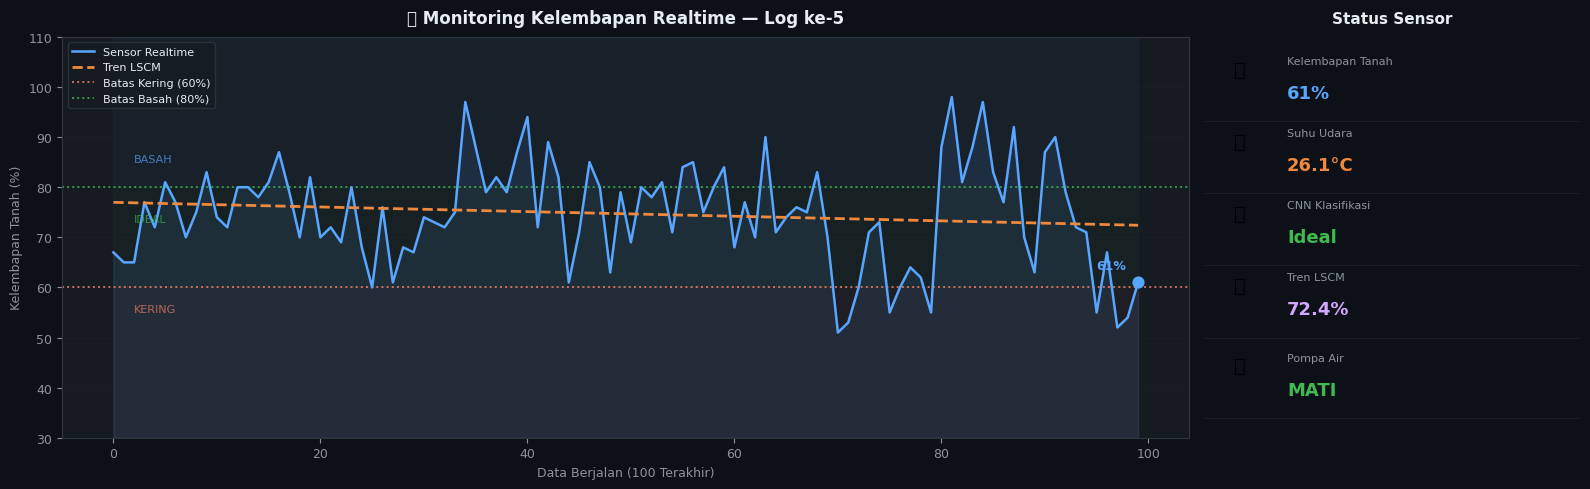

 DATA DASHBOARD MONITORING REALTIME - LOG KE-5
 🟢 BACA SENSOR -> Kelembapan Tanah : 61%  |  Suhu Udara : 26.1°C
 🤖 MODEL CNN   -> Klasifikasi Status: Ideal
 📈 MODEL LSCM  -> Proyeksi Tren     : 72.40%
 ⚡ AUTOMATION  -> Keputusan Pompa   : 🛑 POMPA AIR MATI (Kondisi Ideal)
💡 Tips: Klik tanda kotak hitam (Stop) di kiri cell untuk mengakhiri.

[INFO] Sistem Monitoring Realtime Berhasil Dimatikan Sempurna.


In [44]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - REALTIME ENGINE & VISUALIZATION
# Kelompok 3 🍃
# =========================================================

import time
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from IPython.display import clear_output

# 1. AMBIL KONFIGURASI MODEL & DATASET HISTORIS
print("Mengintegrasikan Model dan Grafik Ke Dalam Sistem Realtime...")
model_realtime = tf.keras.models.load_model("model_cnn_bayam_brazil.h5")

with open("encoder_bayam_brazil.pkl", "rb") as f:
    encoder_realtime = pickle.load(f)

# Membaca data historis asli sebagai basis awal algoritma LSCM
data_historis = pd.read_excel("Data_Kelembapan_Bayam_Brazil_1440.xlsx")

# Membatasi window awal grafik mengambil 100 data terakhir dari excel
kelembapan_history = data_historis['Kelembapan Tanah (%)'].iloc[-100:].values.tolist()
lscm_predictions = []

# Menginisialisasi tren regresi LSCM awal
x_init = np.arange(len(kelembapan_history)).reshape(-1, 1)
regresi_init = LinearRegression().fit(x_init, kelembapan_history)
lscm_predictions = regresi_init.predict(x_init).tolist()

# Fungsi Simulasi Data Masuk dari Sensor IoT (DHT11 / Soil Moisture)
def dapatkan_data_sensor_realtime():
    kelembapan_sekarang = np.random.randint(45, 90)
    suhu_sekarang = round(np.random.uniform(25.0, 33.0), 1)
    return kelembapan_sekarang, suhu_sekarang

# 2. EKSEKUSI PEMANTAUAN REALTIME SENSOR
try:
    counter = 1
    while True:
        # Menangkap data sensor baru
        kelembapan, suhu = dapatkan_data_sensor_realtime()

        # Menyisipkan data sensor baru ke riwayat
        kelembapan_history.append(kelembapan)

        # Kalkulasi Ulang Algoritma LSCM
        x = np.arange(len(kelembapan_history)).reshape(-1, 1)
        regresi = LinearRegression()
        regresi.fit(x, kelembapan_history)
        lscm_predictions = regresi.predict(x).tolist()
        tren_berikutnya = lscm_predictions[-1]

        # Slide Windowing: hanya 100 data berjalan terakhir
        if len(kelembapan_history) > 100:
            kelembapan_history.pop(0)
            lscm_predictions.pop(0)

        # Pemrosesan Klasifikasi CNN
        input_sensor = np.array([[kelembapan, suhu]]).reshape(1, 2, 1)
        prediksi_output = model_realtime.predict(input_sensor, verbose=0)
        kelas_id = np.argmax(prediksi_output)
        status_tanah_cnn = encoder_realtime.inverse_transform([kelas_id])[0]

        # Logika Otomatisasi Pompa Air
        if kelembapan < 60:
            status_pompa = "🔥 POMPA AIR MENYALA (Tanah Kering)"
        elif 60 <= kelembapan <= 79:
            status_pompa = "🛑 POMPA AIR MATI (Kondisi Ideal)"
        else:
            status_pompa = "❌ POMPA AIR MATI (Tanah Terlalu Basah)"

        # Bersihkan output lama
        clear_output(wait=True)

        # ✅ Grafik menarik (fungsi dari Cell 1)
        plot_realtime_menarik(
            kelembapan_history, lscm_predictions,
            kelembapan, suhu, status_tanah_cnn,
            status_pompa, tren_berikutnya, counter
        )

        # Log teks di bawah grafik
        print("=" * 70)
        print(f" DATA DASHBOARD MONITORING REALTIME - LOG KE-{counter}")
        print("=" * 70)
        print(f" 🟢 BACA SENSOR -> Kelembapan Tanah : {kelembapan}%  |  Suhu Udara : {suhu}°C")
        print(f" 🤖 MODEL CNN   -> Klasifikasi Status: {status_tanah_cnn}")
        print(f" 📈 MODEL LSCM  -> Proyeksi Tren     : {tren_berikutnya:.2f}%")
        print(f" ⚡ AUTOMATION  -> Keputusan Pompa   : {status_pompa}")
        print("=" * 70)
        print("💡 Tips: Klik tanda kotak hitam (Stop) di kiri cell untuk mengakhiri.")

        time.sleep(2)
        counter += 1

except KeyboardInterrupt:
    print("\n[INFO] Sistem Monitoring Realtime Berhasil Dimatikan Sempurna.")

[INFO] Model CNN 2D dan Label Map berhasil diintegrasikan!


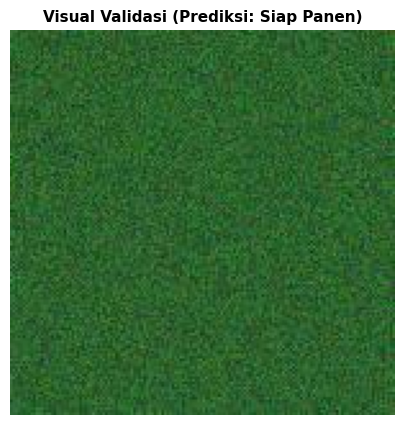

        HASIL EKSTRAKSI GEOMETRI & WARNA TANAMAN (CNN 2D)       
 HASIL DETEKSI SISTEM : SIAP_PANEN
 TINGKAT KEYAKINAN AI : 100.00% Confidence Score
-----------------------------------------------------------------
 KESIMPULAN & ANALISIS FITUR KLASIFIKASI:
 🍃 STATUS REKOMENDASI : [ SEGERA LAKUKAN PEMANENAN ]
 📌 Indikator Daun     : Daun bagian atas sudah MELEBAR (minimal selebar jempol/koin).
 📌 Indikator Warna    : Hijau segar pekat dan tekstur daun tebal/renyah.
 📌 Indikator Rimbun   : Kondisi rimbun penuh, lebat, dan saling menutupi pot.
                         (Aman dipotong, tanaman tidak akan gundul).


In [45]:
# =========================================================
# SMART FARMING BAYAM BRAZIL - INFERENCE TEST 3 PARAMETER
# Kelompok 3 🍃 - Deteksi Berdasarkan Kriteria Daun & Kepadatan
# =========================================================

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# 1. MEMUAT MODEL DAN LABEL MAP YANG SUDAH DILATIH
MODEL_PATH = "model_cnn2d_bayam_3kelas.h5"
LABEL_PATH = "label_map_panen.pkl"

if os.path.exists(MODEL_PATH) and os.path.exists(LABEL_PATH):
    model_pakar = tf.keras.models.load_model(MODEL_PATH)
    with open(LABEL_PATH, "rb") as f:
        label_map = pickle.load(f)
    print("[INFO] Model CNN 2D dan Label Map berhasil diintegrasikan!")
else:
    print("[ERROR] File model atau label map tidak ditemukan. Pastikan Anda sudah menjalankan Cell 4.")

# 2. FUNGSI UTAMA ANALISIS CITRA (COMPUTER VISION)
def analisis_pemanenan_bayam(path_foto_daun):
    """
    Fungsi untuk memprediksi kesiapan panen Bayam Brazil
    berdasarkan visual warna, lebar daun, dan kepadatan rimbun.
    """
    if not os.path.exists(path_foto_daun):
        print(f"[ERROR] File foto '{path_foto_daun}' tidak ditemukan di direktori Colab.")
        return

    # Preprocessing citra input agar sesuai dengan format training CNN (150x150)
    img = image.load_img(path_foto_daun, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Normalisasi skala piksel

    # Eksekusi Prediksi Menggunakan Lapisan Softmax CNN 2D
    prediksi_matriks = model_pakar.predict(img_array, verbose=0)[0]
    indeks_tertinggi = np.argmax(prediksi_matriks)
    status_terpilih = label_map[indeks_tertinggi]
    persentase_yakin = prediksi_matriks[indeks_tertinggi] * 100

    # Tampilkan Foto Tanaman yang Diuji
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Visual Validasi (Prediksi: {status_terpilih.replace('_', ' ').title()})", fontsize=11, fontweight='bold')
    plt.axis('off')
    plt.show()

    # 3. OUTPUT LOGIKA KEPUTUSAN BERDASARKAN INDIKATOR FISIK BOTANI
    print("="*65)
    print("        HASIL EKSTRAKSI GEOMETRI & WARNA TANAMAN (CNN 2D)       ")
    print("="*65)
    print(f" HASIL DETEKSI SISTEM : {status_terpilih.upper()}")
    print(f" TINGKAT KEYAKINAN AI : {persentase_yakin:.2f}% Confidence Score")
    print("-"*65)
    print(" KESIMPULAN & ANALISIS FITUR KLASIFIKASI:")

    if status_terpilih == 'belum_panen':
        print(" ❌ STATUS REKOMENDASI : [ JANGAN DIPANEN ]")
        print(" 📌 Indikator Daun     : Daun di bagian atas masih menguncup kecil / sempit.")
        print(" 📌 Indikator Warna    : Dominan hijau sangat muda transparan.")
        print(" 📌 Indikator Rimbun   : Tanaman masih renggang, belum penuh dalam pot.")

    elif status_terpilih == 'mendekati_panen':
        print(" ⏳ STATUS REKOMENDASI : [ MONITORING BERKALA / 1-2 MINGGU LAGI ]")
        print(" 📌 Indikator Daun     : Ukuran lebar daun mulai berkembang ke ukuran sedang.")
        print(" 📌 Indikator Warna    : Gradasi hijau mulai normal (menuju hijau segar).")
        print(" 📌 Indikator Rimbun   : Cabang samping mulai tumbuh aktif mengisi ruang pot.")

    elif status_terpilih == 'siap_panen':
        print(" 🍃 STATUS REKOMENDASI : [ SEGERA LAKUKAN PEMANENAN ]")
        print(" 📌 Indikator Daun     : Daun bagian atas sudah MELEBAR (minimal selebar jempol/koin).")
        print(" 📌 Indikator Warna    : Hijau segar pekat dan tekstur daun tebal/renyah.")
        print(" 📌 Indikator Rimbun   : Kondisi rimbun penuh, lebat, dan saling menutupi pot.")
        print("                         (Aman dipotong, tanaman tidak akan gundul).")

    print("="*65)

# =========================================================
# 4. SIMULASI JALANKAN PENGUJIAN FOTO
# =========================================================
# Untuk keperluan demo, kita panggil salah satu gambar tiruan dari folder 'mendekati_panen'.
# TIPS: Jika ingin menguji dengan foto asli Anda, silakan unggah foto ke menu Files di kiri,
# lalu ubah tulisan di dalam tanda petik di bawah ini dengan nama file foto Anda (misal: "bayam_ku.jpg")

contoh_file_tes = "dataset_daun_v2/siap_panen/daun_lebar_14.jpg"
analisis_pemanenan_bayam(contoh_file_tes)

In [47]:
from google.colab import files

files.download('model_cnn_bayam_brazil.h5')
files.download('encoder_bayam_brazil.pkl')
# Download notebook utama

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>